[*********************100%***********************]  1 of 1 completed


                            OLS Regression Results                            
Dep. Variable:          Excess_Return   R-squared:                       0.729
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     49.35
Date:                Fri, 28 Aug 2026   Prob (F-statistic):           1.30e-15
Time:                        04:10:49   Log-Likelihood:                -172.29
No. Observations:                  59   AIC:                             352.6
Df Residuals:                      55   BIC:                             360.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4088      0.620      2.273      0.0

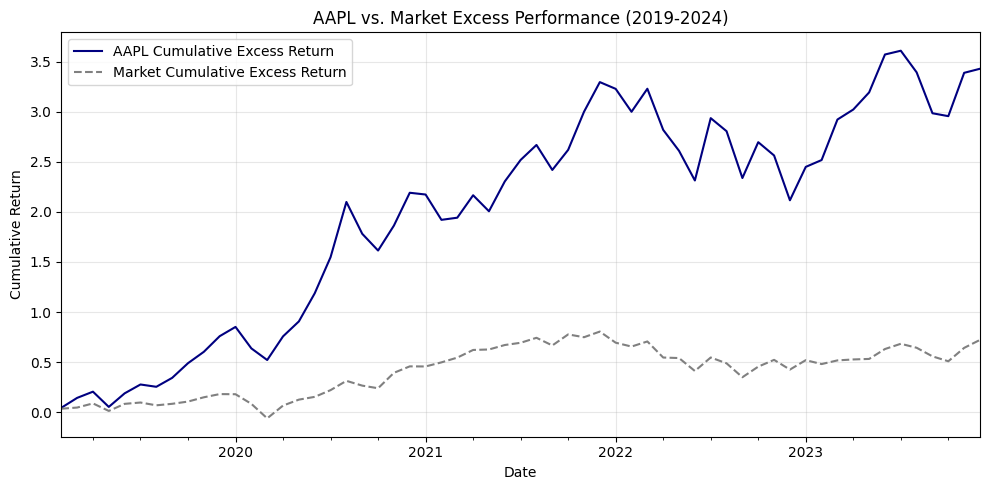

In [6]:
!pip install yfinance pandas-datareader statsmodels matplotlib

import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import statsmodels.api as sm
import matplotlib.pyplot as plt

# 1. Download monthly stock price data
ticker = 'AAPL'
start_date = '2019-01-01'
end_date = '2024-01-01'

# Explicitly download single series with auto_adjust=True
raw_data = yf.download(ticker, start=start_date, end=end_date, interval='1mo', auto_adjust=True)

# Select 'Close' (works across both single-level and MultiIndex structures)
if isinstance(raw_data.columns, pd.MultiIndex):
    stock_data = raw_data['Close'][ticker]
else:
    stock_data = raw_data['Close']

# Calculate monthly returns in percentage
stock_returns = stock_data.pct_change().dropna() * 100
stock_returns.name = 'Stock_Return'
stock_returns.index = stock_returns.index.to_period('M')

# 2. Download Fama-French 3 Factors (Monthly)
ff_factors = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start=start_date, end=end_date)[0]

# 3. Merge stock returns and factor data
df = pd.merge(stock_returns, ff_factors, left_index=True, right_index=True)

# Calculate excess return: R_i - R_f
df['Excess_Return'] = df['Stock_Return'] - df['RF']
df.head()

# Define independent variables (Factors) and add a constant (Alpha)
X = df[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)

# Define dependent variable (Stock Excess Return)
y = df['Excess_Return']

# Fit the Ordinary Least Squares (OLS) model
model = sm.OLS(y, X).fit()

# Display the regression table
print(model.summary())

# Plot Cumulative Excess Return vs Market Excess Return
plt.figure(figsize=(10, 5))
((1 + df['Excess_Return']/100).cumprod() - 1).plot(label='AAPL Cumulative Excess Return', color='navy')
((1 + df['Mkt-RF']/100).cumprod() - 1).plot(label='Market Cumulative Excess Return', color='gray', linestyle='--')
plt.title('AAPL vs. Market Excess Performance (2019-2024)', fontsize=12)
plt.ylabel('Cumulative Return')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('performance_plot.png')
plt.savefig("AAPL_market_performance.png", dpi=300, bbox_inches="tight")
plt.show()